# Perching a fixed-wing UAV with Nonlinear MPC

Fly a small fixed-wing UAV into a *perched landing*: enter fast and level, then
pitch up past the stall so the wing acts as an air brake, and arrive at a target
point nearly stopped and nose-high — the way a bird lands on a branch. The
maneuver lives deep in the **stalled** regime, where the usual
"lift ∝ angle of attack" assumption is wrong, so it needs the *nonlinear* model.

We take a Modelica model of the aircraft, export it with Rumoca to a **CasADi**
module, and build a **nonlinear model-predictive controller (NMPC)** that
optimizes the elevator and throttle to land the perch.

**Export step** — Rumoca compiles the Modelica source into the CasADi module this notebook imports (run once, already done for you):

```bash
rumoca compile model/perch.mo -m Perch --target casadi-mx -o _generated/casadi
```

That writes `_generated/casadi/Perch_casadi_mx.py` — machine-generated, never hand-edited.


## 1. The Modelica model

`model/perch.mo` is a longitudinal (2-D, vertical-plane) model of a ~1.5 kg UAV.
It has **6 states** and **2 controls**:

| state | meaning | | control | meaning |
|---|---|---|---|---|
| `x`, `z` | position (z up) [m] | | `delta_e` | elevator deflection [rad] |
| `theta` | pitch angle [rad] | | `thrust` | propeller thrust [N] |
| `vx`, `vz` | velocity [m/s] | | | |
| `q` | pitch rate [rad/s] | | | |

The important part is the **aerodynamics**. The lift and drag coefficients blend
*smoothly* between two regimes as the angle of attack `alpha` grows:

* **attached flow** (small `alpha`): the usual airfoil, `CL ≈ CL0 + CLα·alpha`;
* **flat plate** (past the stall): the wing behaves like a barn door —
  `CL ≈ sin(2·alpha)` and `CD ≈ CD_fp·sin²(alpha)`, i.e. enormous drag.

A `tanh` "blend" variable `sigma` slides from 0 → 1 across the stall angle. That
flat-plate drag is the air brake the perch maneuver exploits. Here is the model:


In [1]:
from pathlib import Path
mo = (Path.cwd() / "model" / "perch.mo").read_text()
print(mo)

// =====================================================================
// Perch  —  longitudinal (2-D) fixed-wing UAV for the perching demo.
//
// A small UAV flying in the vertical (x, z) plane. The point of the model
// is the *post-stall* aerodynamics: a smooth blend from an attached-flow
// airfoil to a flat plate once the angle of attack passes the stall angle.
// That flat-plate regime is what makes a "perched landing" possible — the
// aircraft pitches its nose up past the stall and uses the huge broadside
// drag as an air brake to arrive at a point with almost no speed, the way
// a bird lands on a wire.
//
// State (6):  x, z, theta, vx, vz, q
//   x, z   : world position [m]          (z up)
//   theta  : pitch angle [rad]           (0 = nose level)
//   vx, vz : world velocity [m/s]
//   q      : pitch rate [rad/s]          (= der(theta))
//
// Input (2):  delta_e, thrust
//   delta_e : elevator deflection [rad]  (+ = nose up)
//   thrust  : propeller thrust [N]       (alo

### The stall, drawn

Let's plot the lift and drag coefficients the model produces as the angle of
attack sweeps from level flight all the way to broadside. Notice how, past the
stall angle (~15°), lift collapses and drag climbs toward the flat-plate value —
this is the brake.


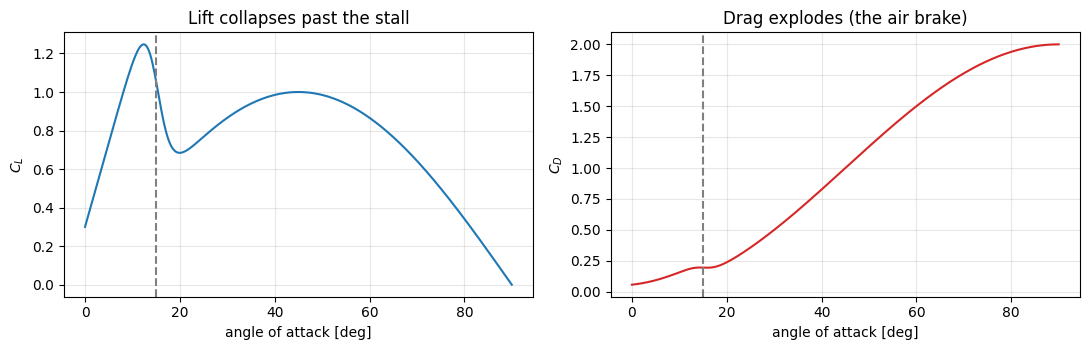

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# the same coefficient laws as in perch.mo
CL0, CLa, CD0, k_ind = 0.30, 5.0, 0.05, 0.08
CD_fp, alpha_stall, blend_width = 2.0, np.deg2rad(15), 0.05

a = np.deg2rad(np.linspace(0, 90, 400))
sigma = 0.5 * (1 + np.tanh((a - alpha_stall) / blend_width))
CL = (1 - sigma) * (CL0 + CLa * a) + sigma * np.sin(2 * a)
CD = (1 - sigma) * (CD0 + k_ind * (CL0 + CLa * a)**2) + sigma * CD_fp * np.sin(a)**2

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(np.rad2deg(a), CL); ax[0].axvline(15, ls="--", c="gray")
ax[0].set_xlabel("angle of attack [deg]"); ax[0].set_ylabel("$C_L$"); ax[0].set_title("Lift collapses past the stall")
ax[1].plot(np.rad2deg(a), CD, c="C3"); ax[1].axvline(15, ls="--", c="gray")
ax[1].set_xlabel("angle of attack [deg]"); ax[1].set_ylabel("$C_D$"); ax[1].set_title("Drag explodes (the air brake)")
for x in ax: x.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 2. Load the CasADi model

CasADi is a symbolic / automatic-differentiation toolbox for optimization: once
the plant is a CasADi object we get exact derivatives for free, which is what the
optimizer needs. Load the generated module and read off the model structure.


In [3]:
import sys
from pathlib import Path
import numpy as np
import casadi as ca

sys.path.insert(0, str(Path.cwd() / "_generated" / "casadi"))
import Perch_casadi_mx as plant

model = plant.create_model()
print("states    :", model["state_names"])
print("inputs    :", model["input_names"])
print("algebraics:", model["algebraic_names"])
print("n_x =", model["n_x"], " n_u =", model["n_u"],
      " n_algebraic =", model["n_z_continuous"])

# state order: x, z, theta, vx, vz, q
IX, IZ, ITH, IVX, IVZ, IQ = range(6)


states    : ['x', 'z', 'theta', 'vx', 'vz', 'q']
inputs    : ['delta_e', 'thrust']
algebraics: ['V', 'alpha', 'qbar', 'sigma', 'Cm', 'CL', 'CD', 'L', 'D']
n_x = 6  n_u = 2  n_algebraic = 9


## 3. From the emitted model to an explicit ODE  `xdot = f(x, u)`

Rumoca emits the model as an **implicit system** (a "DAE"): besides the 6 state
derivatives it carries the named intermediate quantities (`V`, `alpha`, `CL`, …)
as extra unknowns tied together by equations. For the controller we want the
plain explicit form

$$\dot{x} = f(x,\,u)$$

i.e. "given the state and the controls, here is the rate of change of the state."

Because every intermediate is a simple causal formula (`V = sqrt(...)`,
`CL = ...`), recovering `f` is just substituting those definitions in order. The
`explicit_ode()` helper below does exactly that and hands back a CasADi
`Function`.


In [4]:
def explicit_ode(model):
    """Recover xdot = f(x, u) from the implicit residual by causal substitution.

    The casadi-mx backend emits the model as an implicit residual
    f_x(x, xdot, z, u, p) = 0 — one row per state derivative and one per named
    algebraic (V, alpha, CL, ...). For this longitudinal model every algebraic
    is a plain causal assignment, so the system is lower-triangular: solve the
    unknowns one at a time in dependency order and read off the derivatives.
    No iteration, no DAE solver — a clean explicit ODE with exact Jacobians.
    """
    fx = model["f_x"]
    nx, nz = model["n_x"], model["n_z_continuous"]
    prim = {s.name(): s for s in ca.symvar(fx)}
    xdot, zc, x, u, p = prim["xdot"], prim["z_c"], prim["x"], prim["u"], prim["p"]

    # one scalar symbol per unknown w = [xdot; z_c]
    w = [ca.MX.sym(f"w{j}") for j in range(nx + nz)]
    wv = ca.vertcat(*w)
    G = ca.substitute([fx], [xdot, zc],
                      [ca.vertcat(*w[:nx]), ca.vertcat(*w[nx:])])[0]

    # structural Jacobian == true dependency (the model is smooth)
    dep = np.array(ca.DM(ca.jacobian(G, wv).sparsity(), 1.0)) != 0

    # solve a row that contains exactly one still-unknown, inline it, repeat
    sol = [None] * (nx + nz)
    used = np.zeros(fx.shape[0], dtype=bool)
    while any(s is None for s in sol):
        remaining = dep & np.array([s is None for s in sol])[None, :]
        ready = [r for r in range(fx.shape[0])
                 if not used[r] and remaining[r].sum() == 1]
        if not ready:
            raise RuntimeError("model is not causal (algebraic loop)")
        r = ready[0]
        c = int(np.argmax(remaining[r]))
        g = G[r]
        known = [k for k in range(nx + nz) if sol[k] is not None]
        if known:
            g = ca.substitute([g], [w[k] for k in known],
                              [sol[k] for k in known])[0]
        a = ca.jacobian(g, w[c])                       # row is linear in w[c]
        b = ca.substitute([g], [w[c]], [ca.DM(0)])[0]  # g with w[c] = 0
        sol[c] = ca.cse(-b / a)                        # w[c] = -b/a
        used[r] = True

    xdot_expr = ca.vertcat(*sol[:nx])
    p0 = ca.DM(np.asarray(model["p0"], float).flatten())
    xdot_expr = ca.cse(ca.substitute([xdot_expr], [p], [p0])[0])
    return ca.Function("f", [x, u], [xdot_expr], ["x", "u"], ["xdot"])


def rk4_step(f, x, u, dt):
    k1 = f(x, u)
    k2 = f(x + dt / 2 * k1, u)
    k3 = f(x + dt / 2 * k2, u)
    k4 = f(x + dt * k3, u)
    return x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)


f = explicit_ode(model)
f


Function(f:(x[6],u[2])->(xdot[6]) MXFunction)

### Does it respond sensibly? Two quick checks

We don't need a full simulation yet — just confirm the two ingredients the perch
relies on, by evaluating `f` (the rate of change of the state) at a few points:

1. **Pitch authority.** The elevator should command a strong *nose-up* pitch
   acceleration (`q_dot > 0`).
2. **The brake.** At a high angle of attack the drag should be enormous, giving a
   large *deceleration* along the flight path.


In [5]:
deg = np.pi / 180

# 1) pitch authority: q_dot (pitch angular acceleration) vs elevator, at 13 m/s level
x_level = np.array([0, 0, 4*deg, 13.0, 0, 0.0])
print("elevator -> pitch acceleration q_dot:")
for e in [-0.4, 0.0, 0.4]:
    qd = float(f(x_level, [e, 8.0])[IQ])
    print(f"   delta_e = {e:+.1f} rad   ->   q_dot = {qd:+6.1f} rad/s^2")

# 2) the brake: deceleration at a deep angle of attack (nose 70 deg up, still moving forward)
x_stalled = np.array([0, 1.0, 70*deg, 8.0, 0.0, 0.0])
xd = np.array(f(x_stalled, [0.0, 0.0])).flatten()
decel = -(x_stalled[IVX]*xd[IVX] + x_stalled[IVZ]*xd[IVZ]) / np.hypot(x_stalled[IVX], x_stalled[IVZ])
aoa = (x_stalled[ITH] - np.arctan2(x_stalled[IVZ], x_stalled[IVX])) / deg
print(f"\nat angle of attack {aoa:.0f} deg, airspeed 8 m/s:")
print(f"   deceleration along flight path = {decel:.1f} m/s^2   "
      f"(~{decel/9.81:.1f} g of aerodynamic braking)")

elevator -> pitch acceleration q_dot:
   delta_e = -0.4 rad   ->   q_dot =  -60.5 rad/s^2
   delta_e = +0.0 rad   ->   q_dot =   +0.1 rad/s^2
   delta_e = +0.4 rad   ->   q_dot =  +60.6 rad/s^2

at angle of attack 70 deg, airspeed 8 m/s:
   deceleration along flight path = 11.5 m/s^2   (~1.2 g of aerodynamic braking)


## 4. What is Nonlinear Model-Predictive Control (NMPC)?

The control problem: *from a fast level entry, drive the aircraft to a target
"perch" point, arriving nose-up and nearly stopped, using only the elevator and
throttle, and respecting their limits.*

MPC solves this by **planning with the model**:

1. **Predict.** Chop the next ~1.5 s into `N` small steps. Treat the controls at
   each step, `u_0 … u_{N-1}`, as unknowns. Starting from the current state and
   stepping the model `f` forward gives the predicted states `x_1 … x_N` as
   functions of those unknown controls. (This is *multiple shooting*: the states
   are decision variables too, tied together by the dynamics as constraints.)
2. **Score.** Write a **cost**: mostly "how far is the final predicted state from
   the perch (position, attitude, speed)", plus a small penalty on control
   effort. Add **constraints**: elevator ∈ [−0.4, 0.4] rad, thrust ∈ [0, 12] N,
   stay above the ground, don't tumble past vertical.
3. **Optimize.** Hand the whole thing to a numerical optimizer (here **ipopt**),
   which finds the control sequence that minimises the cost subject to the
   constraints. Because `f` is **nonlinear**, this is a *nonlinear program* —
   the "N" in NMPC. (Linear MPC, like the PVTOL demo in this section, gives a
   simpler quadratic program; perching can't be linear because it lives past the
   stall.)
4. **Apply & repeat.** Apply only the first control `u_0`, let the real system
   advance, then re-measure and re-plan. Re-planning each step is what makes it a
   *controller* rather than a one-shot plan, and it rejects disturbances/model
   error.

CasADi's `Opti` lets us write all of this almost exactly as the math reads.


In [6]:
import casadi as ca

N = 55                      # number of prediction steps
tf = 1.45                   # time allotted for the maneuver [s]
dt = tf / N                 # step length [s]

# --- the maneuver: where we start and where the perch is ---
x0      = np.array([0.0, 0.0, 3*deg, 12.0, 0.0, 0.0])     # level, 12 m/s entry
x_perch = np.array([10.0, 1.7, 88*deg, 0.0, 0.0, 0.0])    # ahead, up, nose-vertical, stopped

Wf = np.diag([60., 60., 10., 30., 30., 0.5])    # how much we care about each terminal miss
Re, Rt = 0.05, 5e-3                              # small penalties on control effort

opti = ca.Opti()
X = opti.variable(6, N + 1)      # predicted states (decision variables)
U = opti.variable(2, N)          # controls           (decision variables)

opti.subject_to(X[:, 0] == x0)                                   # start at the entry state
for k in range(N):                                              # dynamics tie the states together
    opti.subject_to(X[:, k + 1] == rk4_step(f, X[:, k], U[:, k], dt))

opti.subject_to(opti.bounded(-0.40, U[0, :], 0.40))             # elevator limits [rad]
opti.subject_to(opti.bounded(0.0,  U[1, :], 12.0))             # thrust limits [N]
opti.subject_to(X[IZ, 1:] >= -0.5)                             # stay above the ground
opti.subject_to(X[ITH, 1:] <= 92*deg)                          # don't tumble past vertical

err = X[:, N] - x_perch                                         # terminal miss
cost = ca.mtimes([err.T, Wf, err])
for k in range(N):
    cost += Re * U[0, k]**2 + Rt * U[1, k]**2                   # control effort
opti.minimize(cost)

# a sensible starting guess keeps the optimizer away from the V→0 singularity
opti.set_initial(X, np.linspace(x0, x_perch, N + 1).T)
opti.set_initial(U, np.tile([[0.0], [4.0]], (1, N)))
opti.solver("ipopt", {"print_time": False}, {"print_level": 0, "tol": 1e-6})

import time
t0 = time.perf_counter()
sol = opti.solve()
print(f"solved the perch in {(time.perf_counter()-t0)*1e3:.0f} ms")
Xs, Us = np.array(sol.value(X)), np.array(sol.value(U))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



solved the perch in 765 ms


## 5. The result — an optimal perch

Let's look at what the optimizer chose. The big picture is the trajectory in the
vertical plane, with the aircraft drawn as a short fuselage at its actual pitch
angle, coloured by airspeed. Then the time histories tell the story: the airspeed
bleeds away, the pitch and angle of attack swing up past the stall, and the
controls saturate as the aircraft fights to the perch.


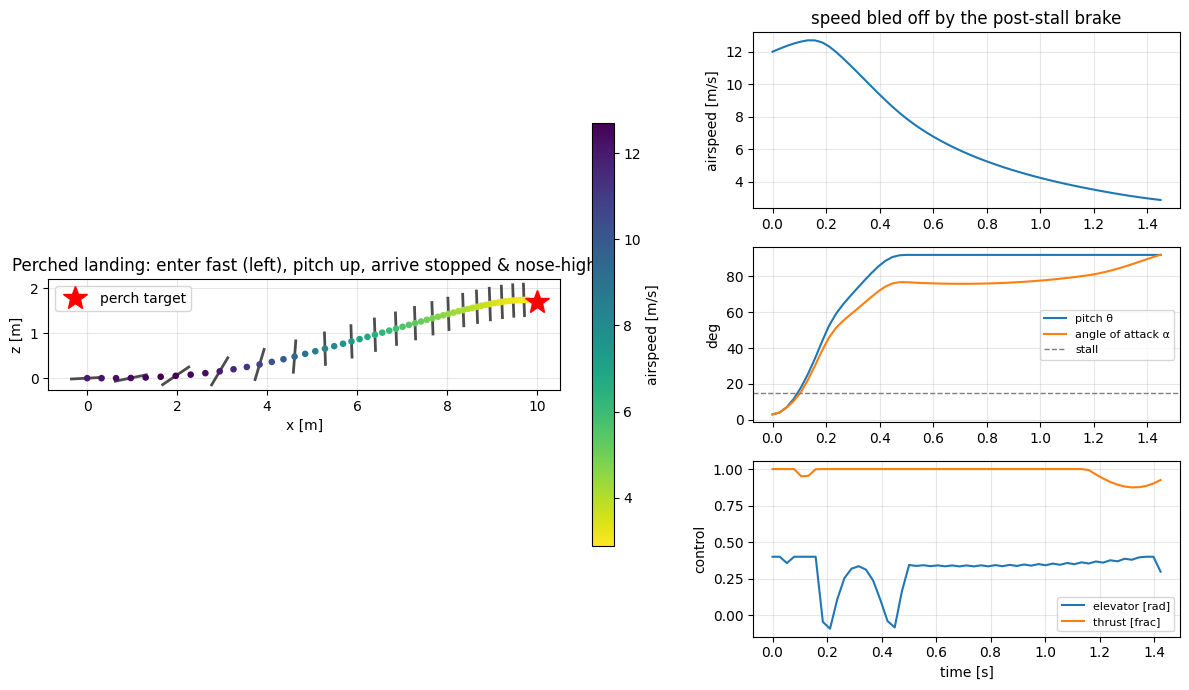

arrival: x=9.78 m  z=1.74 m  pitch=92 deg  speed=2.88 m/s
perch miss: 0.22 m   max AoA: 92 deg


In [7]:
t = np.arange(N + 1) * dt
V = np.hypot(Xs[IVX], Xs[IVZ])
alpha = Xs[ITH] - np.arctan2(Xs[IVZ], Xs[IVX])

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(3, 2, width_ratios=[1.5, 1])

# --- trajectory with aircraft glyphs ---
axT = fig.add_subplot(gs[:, 0])
sc = axT.scatter(Xs[IX], Xs[IZ], c=V, cmap="viridis_r", s=14, zorder=3)
L = 0.7
for k in range(0, N + 1, 3):
    th = Xs[ITH, k]
    axT.plot([Xs[IX, k] - L/2*np.cos(th), Xs[IX, k] + L/2*np.cos(th)],
             [Xs[IZ, k] - L/2*np.sin(th), Xs[IZ, k] + L/2*np.sin(th)],
             c="0.3", lw=2, zorder=2)
axT.plot(*x_perch[[IX, IZ]], "r*", ms=18, zorder=4, label="perch target")
axT.set_xlabel("x [m]"); axT.set_ylabel("z [m]"); axT.set_aspect("equal")
axT.set_title("Perched landing: enter fast (left), pitch up, arrive stopped & nose-high")
axT.legend(loc="upper left"); axT.grid(alpha=.3)
fig.colorbar(sc, ax=axT, label="airspeed [m/s]", shrink=.7)

# --- time histories ---
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(t, V); ax1.set_ylabel("airspeed [m/s]"); ax1.grid(alpha=.3)
ax1.set_title("speed bled off by the post-stall brake")
ax2 = fig.add_subplot(gs[1, 1])
ax2.plot(t, np.rad2deg(Xs[ITH]), label="pitch θ")
ax2.plot(t, np.rad2deg(alpha), label="angle of attack α")
ax2.axhline(15, ls="--", c="gray", lw=1, label="stall")
ax2.set_ylabel("deg"); ax2.legend(fontsize=8); ax2.grid(alpha=.3)
ax3 = fig.add_subplot(gs[2, 1])
ax3.plot(t[:-1], Us[0], label="elevator [rad]")
ax3.plot(t[:-1], Us[1] / 12, label="thrust [frac]")
ax3.set_xlabel("time [s]"); ax3.set_ylabel("control"); ax3.legend(fontsize=8); ax3.grid(alpha=.3)
plt.tight_layout(); plt.show()

xf = Xs[:, -1]
print(f"arrival: x={xf[IX]:.2f} m  z={xf[IZ]:.2f} m  pitch={xf[ITH]/deg:.0f} deg  speed={np.hypot(xf[IVX],xf[IVZ]):.2f} m/s")
print(f"perch miss: {np.hypot(xf[IX]-x_perch[IX], xf[IZ]-x_perch[IZ]):.2f} m   max AoA: {np.max(alpha)/deg:.0f} deg")

## 6. Run the perch in Rumoca's own simulator

Rumoca can integrate the model directly with `rumoca sim` — no external Modelica
tool. It has no time-series input forcing, so we bake the optimal controls into
the model. The optimizer's controls are piecewise-constant; the cell below
reconstructs them as a **continuous, piecewise-linear** function of `time` (a sum
of clamped ramps), which Rumoca's ODE solver applies directly, and starts the
plant from the entry state `x0`.

It prints a **self-contained** Modelica file (the `Perch` plant plus a
`PerchReplay` wrapper). Save the printed text as a `.mo` in its own empty folder
(Rumoca scans the model's directory, so keep it away from `model/perch.mo`) and
run it with the explicit solver — the maneuver is non-stiff:

```bash
rumoca sim perch_replay.mo -m PerchReplay --t-end 1.45 --solver rk-like --dt 0.01
```

That writes an HTML report whose `z, theta, V` track the `Xs` plotted above: the
original Modelica plant, simulated by Rumoca, flies the same perch the controls
were planned for (modulo a small offset, since the replay linearly interpolates
the optimizer's zero-order-hold samples).


In [8]:
# Emit a self-contained, runnable Modelica replay of the optimal solve.
# The optimizer's controls are piecewise-constant; we reconstruct them as a
# continuous, event-free piecewise-LINEAR function of time (a sum of clamped
# ramps) so Rumoca's ODE integrator can apply them directly.
def _arr(v):
    return "{" + ", ".join(f"{x:.6g}" for x in v) + "}"

plant_src = (Path.cwd() / "model" / "perch.mo").read_text().rstrip()

wrapper = f"""
model PerchReplay "Replay the MPC-optimal controls through the Perch plant"
  parameter Integer N  = {N};
  parameter Real    dt = {dt:.8f} "control step [s]";
  parameter Real de[N] = {_arr(Us[0])} "optimal elevator samples [rad]";
  parameter Real th[N] = {_arr(Us[1])} "optimal thrust samples [N]";
  Perch plant(
    x(start = {x0[IX]:.6g}),  z(start = {x0[IZ]:.6g}),  theta(start = {x0[ITH]:.6g}),
    vx(start = {x0[IVX]:.6g}), vz(start = {x0[IVZ]:.6g}), q(start = {x0[IQ]:.6g}));
equation
  // piecewise-linear interpolation of the control samples (continuous, no events)
  plant.delta_e = de[1] + sum((de[j+1]-de[j])*max(0.0, min(1.0, (time-(j-1)*dt)/dt)) for j in 1:N-1);
  plant.thrust  = th[1] + sum((th[j+1]-th[j])*max(0.0, min(1.0, (time-(j-1)*dt)/dt)) for j in 1:N-1);
end PerchReplay;
"""

perch_replay_mo = plant_src + "\n\n\n" + wrapper.lstrip()
print(perch_replay_mo)
print("\n# Save the text above as perch_replay.mo in its OWN empty folder, then run:")
print(f"#   rumoca sim perch_replay.mo -m PerchReplay --t-end {tf:.2f} --solver rk-like --dt 0.01")


// =====================================================================
// Perch  —  longitudinal (2-D) fixed-wing UAV for the perching demo.
//
// A small UAV flying in the vertical (x, z) plane. The point of the model
// is the *post-stall* aerodynamics: a smooth blend from an attached-flow
// airfoil to a flat plate once the angle of attack passes the stall angle.
// That flat-plate regime is what makes a "perched landing" possible — the
// aircraft pitches its nose up past the stall and uses the huge broadside
// drag as an air brake to arrive at a point with almost no speed, the way
// a bird lands on a wire.
//
// State (6):  x, z, theta, vx, vz, q
//   x, z   : world position [m]          (z up)
//   theta  : pitch angle [rad]           (0 = nose level)
//   vx, vz : world velocity [m/s]
//   q      : pitch rate [rad/s]          (= der(theta))
//
// Input (2):  delta_e, thrust
//   delta_e : elevator deflection [rad]  (+ = nose up)
//   thrust  : propeller thrust [N]       (alo

## 7. Closing the loop — that's the "Control" in NMPC

So far we solved the plan **once**. A real controller re-plans continuously: it
measures the current state, re-solves the perch problem over the time *remaining*,
applies the first control for one short step, and repeats. The horizon **shrinks**
as the perch approaches. Below we run that closed loop against the model and time
each re-solve.

(This is a Python + ipopt prototype, so each re-solve is tens-to-hundreds of
milliseconds; a deployed controller would use a warm-started SQP / code-generated
solver to hit a hard real-time rate. The point here is the *behavior*: re-planning
each step still lands the perch.)


In [9]:
dt_ctrl = 0.02
n_steps = round(tf / dt_ctrl)
x = x0.copy()
Xlog, Ulog, ms = [x.copy()], [], []
Xg = np.linspace(x0, x_perch, N + 1).T
Ug = np.tile([[0.0], [4.0]], (1, N))

for i in range(n_steps):
    remaining = tf - i * dt_ctrl
    # re-plan over the time remaining: build the problem at the current state,
    # with the horizon spanning [now, perch] in N steps, and re-solve.
    o = ca.Opti(); Xv = o.variable(6, N+1); Uv = o.variable(2, N)
    o.subject_to(Xv[:, 0] == x)
    dtk = remaining / N
    for k in range(N):
        o.subject_to(Xv[:, k+1] == rk4_step(f, Xv[:, k], Uv[:, k], dtk))
    o.subject_to(o.bounded(-0.4, Uv[0, :], 0.4)); o.subject_to(o.bounded(0, Uv[1, :], 12))
    o.subject_to(Xv[IZ, 1:] >= -0.5); o.subject_to(Xv[ITH, 1:] <= 92*deg)
    e = Xv[:, N] - x_perch; c = ca.mtimes([e.T, Wf, e])
    for k in range(N): c += Re*Uv[0, k]**2 + Rt*Uv[1, k]**2
    o.minimize(c)
    o.set_initial(Xv, Xg); o.set_initial(Uv, Ug)
    o.solver("ipopt", {"print_time": False}, {"print_level": 0, "tol": 1e-6})
    t0 = time.perf_counter(); s = o.solve(); ms.append((time.perf_counter()-t0)*1e3)
    Xg, Ug = s.value(Xv), s.value(Uv)
    u0 = Ug[:, 0]
    for _ in range(4):                       # advance the plant a control period
        x = np.array(rk4_step(f, x, u0, dt_ctrl/4)).flatten()
    Xlog.append(x.copy()); Ulog.append(u0.copy())

Xlog = np.array(Xlog).T; ms = np.array(ms)
xf = Xlog[:, -1]
print(f"closed-loop arrival: x={xf[IX]:.2f} z={xf[IZ]:.2f} pitch={xf[ITH]/deg:.0f} deg "
      f"speed={np.hypot(xf[IVX],xf[IVZ]):.2f} m/s")
print(f"perch miss: {np.hypot(xf[IX]-x_perch[IX], xf[IZ]-x_perch[IZ]):.2f} m")
print(f"re-solve time: mean {ms.mean():.0f} ms, max {ms.max():.0f} ms over {len(ms)} steps")

closed-loop arrival: x=9.78 z=1.68 pitch=91 deg speed=3.04 m/s
perch miss: 0.22 m
re-solve time: mean 271 ms, max 457 ms over 72 steps


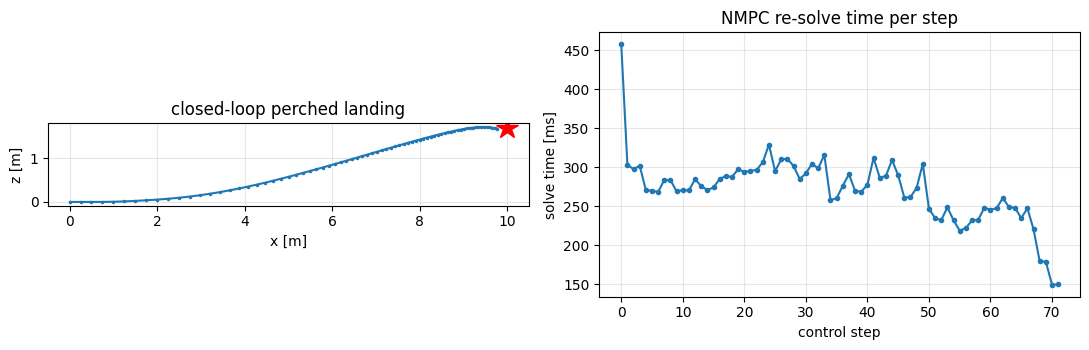

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(Xlog[IX], Xlog[IZ], ".-", ms=3); ax[0].plot(*x_perch[[IX, IZ]], "r*", ms=16)
ax[0].set_aspect("equal"); ax[0].set_xlabel("x [m]"); ax[0].set_ylabel("z [m]")
ax[0].set_title("closed-loop perched landing"); ax[0].grid(alpha=.3)
ax[1].plot(ms, ".-"); ax[1].set_xlabel("control step"); ax[1].set_ylabel("solve time [ms]")
ax[1].set_title("NMPC re-solve time per step"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Why this is the point

* The **controller never knew it was Modelica**, and the **Modelica model never
  knew it was being used for control**. Rumoca's CasADi export is the only thing
  connecting them — change `perch.mo` and re-run, and the controller's internal
  prediction model updates automatically. No hand-derived equations, no model
  drift between the simulator and the controller.
* The maneuver **requires the nonlinear model**. The aircraft spends the whole
  perch deep past the stall (angle of attack ~90°), where any linearise-about-
  trim controller is simply wrong. The exact nonlinear dynamics — with the
  post-stall flat-plate aero — are what make the optimization meaningful.
* And it is a genuinely hard, recognizable control result: a fixed-wing aircraft
  braking on its own broadside drag to land on a point, like a bird on a wire.
